# First Assignment EE513: Setup and First Captures

In [46]:
# imports:
import rawpy
import imageio.v3 as iio
import os
import rawpy
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

### Environment
1. Build the course environment from the two files on the setup page and run the smoke test notebook.

Deliverable: the version block the smoke test prints, showing Python, NumPy, and OpenCV versions.
From the smoke test:
Python   3.12.14
all required packages import  numpy 2.5.3, scipy 1.18.1, matplotlib 3.11.2, cv2 5.0.0, rawpy 0.27.1, imageio 2.38.0, skimage 0.26.0

2. Create a public GitHub repository for Project 1, with a README naming the camera you intend to characterize and the app you will use to capture raw.

Deliverable: URL 

https://github.com/AlexanderMatteson/Matteson_ee513_project1.git


### Confirm your camera writes real raw

3. Capture one raw photograph of anything, load it. Deliverable: the printed output.

In [9]:
# code to find raw file from the smoke test
from pathlib import Path

RAW_SUFFIXES = {".dng", ".arw", ".cr2", ".cr3", ".nef", ".raf", ".orf", ".rw2", ".pef", ".srw"}

def find_images_dir(start=None):
    """Walk up from the notebook looking for a directory named Images."""
    here = (start or Path.cwd()).resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "Images"
        if candidate.is_dir():
            return candidate
    return None

def find_raw_files():
    roots = [p for p in (find_images_dir(), Path.cwd(), Path.home() / "Downloads") if p]
    seen, found = set(), []
    for root in roots:
        if root in seen:
            continue
        seen.add(root)
        for path in sorted(root.rglob("*")):
            if path.suffix.lower() in RAW_SUFFIXES and path.is_file():
                found.append(path)
    return found

IMAGES_DIR = find_images_dir()
print("Images directory:", IMAGES_DIR or "not found")

raws = find_raw_files()
if raws:
    print(f"Found {len(raws)} raw file(s). Using: {raws[0].name}")
else:
    print("No raw files found yet.")




Images directory: C:\Users\ammat\OneDrive\Documents\ee513\Images
Found 2 raw file(s). Using: IMG_0009.DNG


In [10]:
import rawpy

file_raw = r"C:\Users\ammat\OneDrive\Documents\ee513\Images\IMG_0009.DNG"

with rawpy.imread(file_raw) as raw:
    print("raw_type:", raw.raw_type)

    print("\nraw_image_visible:")
    print("  shape =", raw.raw_image_visible.shape)
    print("  dtype =", raw.raw_image_visible.dtype)

    print("\nraw_pattern:")
    print(raw.raw_pattern)

    print("\ncolor_desc:")
    print(raw.color_desc)

    print("\nblack_level_per_channel:")
    print(raw.black_level_per_channel)

    print("\nwhite_level:")
    print(raw.white_level)

raw_type: RawType.Flat

raw_image_visible:
  shape = (3024, 4032)
  dtype = uint16

raw_pattern:
[[0 1]
 [3 2]]

color_desc:
b'RGBG'

black_level_per_channel:
[528, 528, 528, 528]

white_level:
4095


4. State in one sentence whether you have a Bayer mosaic. Deliverable: a one-sentence verdict, and the CFA layout as four letters, for example RGGB or BGGR.

I believe the bayer mosaic refers to what you discribed in class where each pixel sensor collects either a r, g, or b, raw pattern gives use a 2x2 matrix and the raw type is flat, so I believe this is telling us that there is a 2D raw image array and the r,g,b is in a 2x2 sections where each pixel in that 2x2 is either r,g, or b. 

5. Deliverable: a written statement, or "not applicable" if item 4 succeeded.

    not applicatable

### What the ordinary photo path threw away

6. Capture the same scene twice without moving the camera, once as raw and once as an ordinary JPEG or HEIC. Report the file size, bit depth, and number of channels of each.
Deliverable: a small table with both files.


In [44]:
import os
from PIL import Image
import numpy as np
import rawpy

# load the raw image and report the file size, bit depth, and # of channels
file_raw = r"C:\Users\ammat\OneDrive\Documents\ee513\Images\Image2_raw.DNG"

# File size on disk
raw_size = os.path.getsize(file_raw)

with rawpy.imread(file_raw) as raw:

    # Raw sensor image
    img_raw = raw.raw_image_visible

    # Bit depth from datatype
    bit_depth_raw = img_raw.dtype.itemsize * 8

    # Number of channels
    if len(img_raw.shape) == 2:
        channels_raw = 1
    else:
        channels_raw = img_raw.shape[2]

    print("File size:", raw_size, "bytes")
    print("Image shape:", img_raw.shape)
    print("Bit depth:", bit_depth_raw, "bits")
    print("Number of channels:", channels_raw)

# JPEG image
file_jpg = r"C:\Users\ammat\OneDrive\Documents\ee513\Images\Image2_normal.jpg"

# File size on disk
jpg_size = os.path.getsize(file_jpg)

# Open image
img = Image.open(file_jpg)

# Convert to NumPy array
img_array = np.array(img)

# Determine bit depth
jpg_bit_depth = img_array.dtype.itemsize * 8

# Determine number of channels
if len(img_array.shape) == 2:
    jpg_channels = 1
else:
    jpg_channels = img_array.shape[2]

print("File size:", jpg_size, "bytes")
print("Image shape:", img_array.shape)
print("Bit depth:", jpg_bit_depth, "bits")
print("Number of channels:", jpg_channels)

File size: 10596435 bytes
Image shape: (3024, 4032)
Bit depth: 16 bits
Number of channels: 1
File size: 394382 bytes
Image shape: (1920, 1440, 3)
Bit depth: 8 bits
Number of channels: 3


In [45]:
import pandas as pd

summary = pd.DataFrame(
    {
        "File size (MB)": [raw_size / 1e6, jpg_size / 1e6],
        "Bit depth (bits)": [bit_depth_raw, jpg_bit_depth],
        "Channels": [channels_raw, jpg_channels],
    },
    index=["RAW (DNG)", "JPEG"],
)

summary.round(2)

,File size (MB),Bit depth (bits),Channels
RAW (DNG),10.60,16,1
JPEG,0.39,8,3


7. Display a region of about 30 by 30 pixels of the raw data, zoomed so that individual pixels are visible as blocks.
Deliverable: the figure, and a sentence identifying what the checkerboard texture is. It is not noise.

I believe that the scquare grid pattern is due to the bayer mosaic we talked about earlier, where each pixel in the 2x2 section is getting a different color.

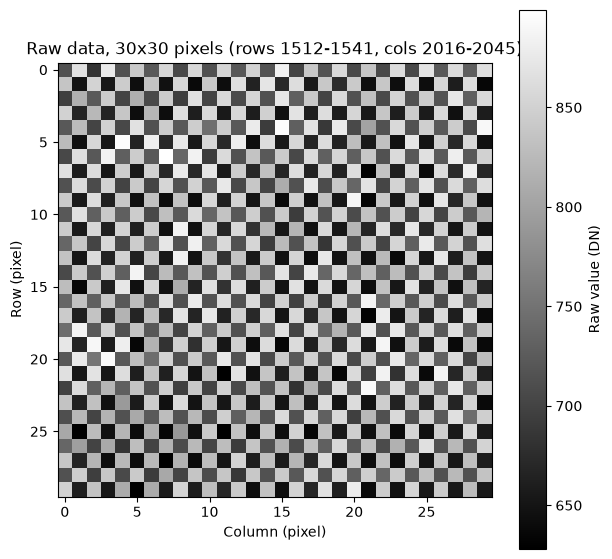

In [47]:
# load the raw image (i know I did this above already)
with rawpy.imread(file_raw) as raw:
    img_raw = raw.raw_image_visible.copy()   # .copy() is important
    bayer_pattern = raw.raw_pattern.copy()   # 2x2 CFA layout (optional, used below)
    color_desc = raw.color_desc              # e.g. b'RGBG'

# look at the 30x30 region:
# Choose a 30x30 region (start on even row/col so the Bayer pattern lines up)
size = 30
r0 = (img_raw.shape[0] // 2) // 2 * 2
c0 = (img_raw.shape[1] // 2) // 2 * 2
patch = img_raw[r0:r0+size, c0:c0+size]

plt.figure(figsize=(7, 7))
plt.imshow(patch, cmap="gray", interpolation="nearest")
plt.colorbar(label="Raw value (DN)")
plt.title(f"Raw data, {size}x{size} pixels (rows {r0}-{r0+size-1}, cols {c0}-{c0+size-1})")
plt.xlabel("Column (pixel)")
plt.ylabel("Row (pixel)")
plt.show()

8. Name three things the camera's own pipeline did to the JPEG that cannot be undone afterwards, and say for each one why it is irreversible.
Deliverable: a short written answer, three or four sentences.

First, I believe that going from bayer mosaic to a normal color image (wilipedia said this process is called Demosaicing) would be irriverible, I believe this would be because of the interpolation used to determine the color based on the pixel colors near by. Second, maybe I think I've heard many new cameras use AI models to adjust images to make them look nicer, reduce nose, and fix the scenes, this would be irriversible unless you saved the raw version because the AI is making up information and adding it to the image. Last, maybe denoising filters that smooth or average pixel values to reduce noise may cause loss of the raw pixel information because of the averaging or smoothing.

### First calibration captures

9. Print the calibration target at 100% scale and tape it flat to card or board. Measure one square with a ruler and report the measured size in millimetres.
Deliverable: the measured square size, and one sentence on why you will use your measured value rather than the nominal 20.0 mm.

I measure a size of 19.0 mm x 19.0 mm. I will use my measured value because if I use 20.0mm the calibration will be based on an incorrect value and the results will be off.

10. Capture at least 15 photographs of the target at a variety of angles, distances, and positions in the frame, including several where the board is tilted well away from parallel and several where it sits near a corner of the frame.
Deliverable: a contact sheet of your captures.

Target1.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target1.jpg
Target2.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target2.jpg
Target3.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target3.jpg
Target4.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target4.jpg
Target5.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target5.jpg
Target6.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target6.jpg
Target7.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target7.jpg
Target8.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target8.jpg
Target9.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target9.jpg
Target10.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target10.jpg
Target11.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target11.jpg
Target12.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target12.jpg
Target13.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target13.jpg
Target14.jpg
C:\Users\ammat\OneDrive\Documents\ee513\Images\Target14.

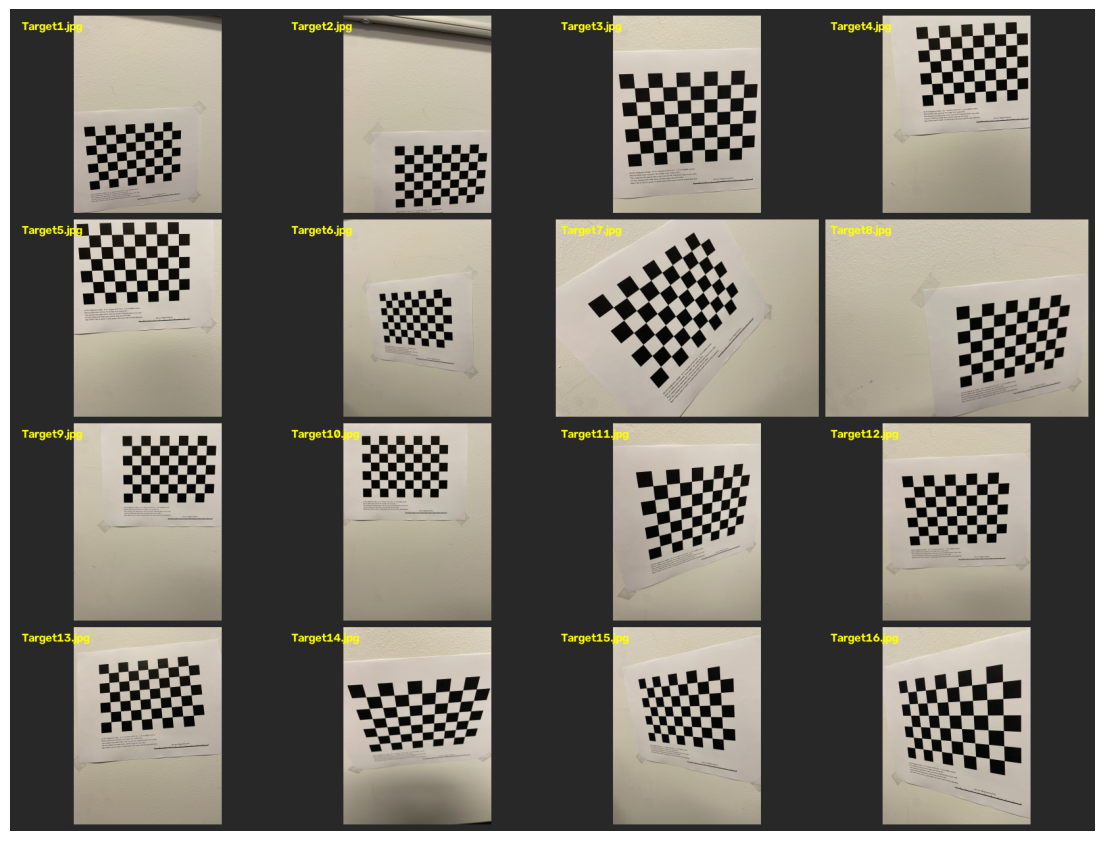

In [57]:
"""Build a 4x4 contact sheet from Target1.jpg ... Target16.jpg.

Usage:
    python contact_sheet.py                 # images in the current folder
    python contact_sheet.py path/to/folder  # images in another folder
"""
import sys
from pathlib import Path

import cv2
import numpy as np

FOLDER = r"C:\Users\ammat\OneDrive\Documents\ee513\Images"
N_IMAGES = 16
ROWS, COLS = 4, 4
THUMB_W, THUMB_H = 400, 300   # size of each cell in the sheet (pixels)
PAD = 10                      # gap between cells
BG = (40, 40, 40)             # dark grey background


def make_thumb(img, w, h):
    """Shrink img to fit inside w x h without distorting it; pad the rest."""
    ih, iw = img.shape[:2]
    scale = min(w / iw, h / ih)
    new_w, new_h = int(iw * scale), int(ih * scale)
    small = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    cell = np.full((h, w, 3), BG, dtype=np.uint8)
    x0, y0 = (w - new_w) // 2, (h - new_h) // 2
    cell[y0:y0 + new_h, x0:x0 + new_w] = small
    return cell


sheet_w = COLS * THUMB_W + (COLS + 1) * PAD
sheet_h = ROWS * THUMB_H + (ROWS + 1) * PAD
sheet = np.full((sheet_h, sheet_w, 3), BG, dtype=np.uint8)

loaded = 0
for i in range(N_IMAGES):
    name = f"Target{i + 1}.jpg"
    print(name)
    print(FOLDER + "\\" + name)
    img = cv2.imread(FOLDER + "\\" + name)
    if img is None:
        print(f"WARNING: could not read {name}")
        continue
    loaded += 1

    cell = make_thumb(img, THUMB_W, THUMB_H)
    cv2.putText(cell, name, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (0, 255, 255), 2, cv2.LINE_AA)

    r, c = divmod(i, COLS)
    y = PAD + r * (THUMB_H + PAD)
    x = PAD + c * (THUMB_W + PAD)
    sheet[y:y + THUMB_H, x:x + THUMB_W] = cell

print(f"Loaded {loaded}/{N_IMAGES} images")

out_path = FOLDER + "\\" + "contact_sheet.jpg"
cv2.imwrite(str(out_path), sheet, [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Saved {out_path}")

# display 
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 11))
plt.imshow(cv2.cvtColor(sheet, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

11. Run cv2.findChessboardCorners with the pattern size (9, 6) on every capture and report how many succeeded.
Deliverable: the count, and one image with the detected corners drawn on it.

Target1.jpg


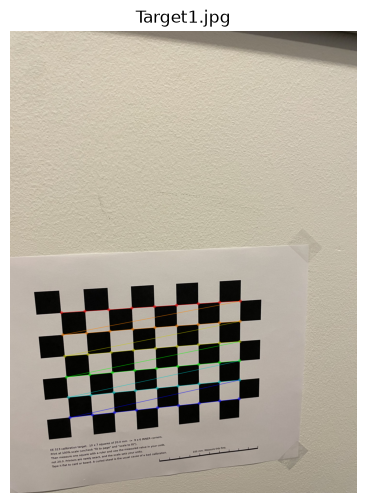

Target2.jpg
Target3.jpg
Target4.jpg
Target5.jpg
Target6.jpg
Target7.jpg
Target8.jpg
Target9.jpg
Target10.jpg
Target11.jpg
Target12.jpg
Target13.jpg
Target14.jpg
Target15.jpg
Target16.jpg
sucessful images: 16 out of 16


In [71]:
FOLDER = r"C:\Users\ammat\OneDrive\Documents\ee513\Images"
N_IMAGES = 16
pattern_size = (9, 6) 
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.
count = 0
for i in range(N_IMAGES):
    name = f"Target{i + 1}.jpg"
    #print(name)
    #print(FOLDER + "\\" + name)
    img = cv2.imread(FOLDER + "\\" + name)

    ret, corners = cv2.findChessboardCorners(img, pattern_size, None)

        # If found, add object points, image points (after refining them)
    if ret == True:
        print(name)
        test = 0
        count +=1;
        if test == 1:
            vis = img.copy()
            cv2.drawChessboardCorners(vis, pattern_size, corners, ret)
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(name)
            plt.axis("off")
            plt.show()
        else:
            if count == 1:
                vis = img.copy()
                cv2.drawChessboardCorners(vis, pattern_size, corners, ret)
                plt.figure(figsize=(8, 6))
                plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
                plt.title(name)
                plt.axis("off")
                plt.show()
                
print("sucessful images: " + str(count) + " out of " + str(N_IMAGES))          
    

12. Pass the successful detections to cv2.calibrateCamera and report the RMS reprojection error it returns. A rough number is fine here; Project 1 is where you will interpret it.
Deliverable: the RMS reprojection error, and one sentence on what it means and what units it is in.

In [75]:
import cv2
import numpy as np

FOLDER = r"C:\Users\ammat\OneDrive\Documents\ee513\Images"
N_IMAGES = 16
pattern_size = (9, 6)
SQUARE_MM = 19.0   # <- replace with your measured square size

# 3D corner positions for one board: (0,0,0), (s,0,0), (2s,0,0) ... on the Z=0 plane
objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= SQUARE_MM

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints = []   # 3D points in real-world space
imgpoints = []   # 2D points in the image plane
image_size = None
n_found = 0

for i in range(N_IMAGES):
    name = f"Target{i + 1}.jpg"
    img = cv2.imread(FOLDER + "\\" + name)
    if img is None:
        print(f"Could not read {name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    image_size = gray.shape[::-1]          # (width, height)

    ret, corners = cv2.findChessboardCorners(gray, pattern_size, None)

    if ret:
        n_found += 1
        print(name)
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp)
        imgpoints.append(corners)

print(f"Detected corners in {n_found}/{N_IMAGES} images")

rms, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, image_size, None, None)

print(f"RMS reprojection error: {rms:.3f} px")
#print("Camera matrix:\n", mtx)
#print("Distortion coefficients:\n", dist.ravel())

Target1.jpg
Target2.jpg
Target3.jpg
Target4.jpg
Target5.jpg
Target6.jpg
Target7.jpg
Target8.jpg
Target9.jpg
Target10.jpg
Target11.jpg
Target12.jpg
Target13.jpg
Target14.jpg
Target15.jpg
Target16.jpg
Detected corners in 16/16 images
RMS reprojection error: 2.588 px


This is the root mean squared distance, it is the difference between where the corners are actually and where the calibrated prediction says they should be, the unit would be pixels.

### Reflections

13. What did you learn from this assignment?
Deliverable: a written response.

It has actually been a bit since I have used python or jupyter notebooks. So, the setting up the enviroment, using jupyter, and even just messing around with writing python scripts was not nesscarily new but definitly required a bit of relearning. This is probably good as I have mostly been using matlab and Python is probably more generally used and it is iportant to be familiar with both. 

14. What questions, if any, do you have for me after completing this assignment?
Deliverable: a written response.

Not really a specific question but I don't feel super confident using git. I know this is a widely used tool and it is important to learn. I think I am on top of it for now but if I come up with problems I will reach out to you. Thanks.

Use of AI tools: I used AI to help with the writing of code for this assignment. For specific tools, I started with copilot and then switched to claude. I have not been writing much python lately so this was very helpful to prevent me from wasting time. To ensure the outputs are correct/make senese: 
First, I tried to write the code or found examples from tutorial to follow. Then when I got stuck I would use the AI to help rewrite/fill in the code. This way I was using the AI just to write code/syntax, as opposed to just giving it the HW problem and letting it come up with an answer. This makes sure I am understaning the process used. Next, I read through all lines of code gernated by the AI to see if they made sense and I could understand what was happening, this also has the benifit of helping me relearn python. Last, I checked all outputs and verified that they were reasonable and defensible given my understandings of the subject matter.